**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: -----------------Miguel Fernando Garcia Pina-----------------------
*   MATRÍCULA: --------------A01046823------------------------------------

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Ciencia Analitica de datos/Semana 6"
os.chdir(DIR)

In [125]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

In [126]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
from scipy.stats import norm
import scipy.stats as stats
from matplotlib.colors import to_rgba

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
*15 columnas numéricas  y 12 columnas de texto*
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [127]:
#Se crea el dataframe compu_df
compu_df = pd.read_csv("computer_prices.csv")

#Método info para resumen de los datos
compu_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

In [128]:
#Valores Únicos por columna
compu_df.nunique()

,0
device_type,2
brand,10
model,99036
release_year,8
os,4
form_factor,10
cpu_brand,3
cpu_model,26971
cpu_tier,6
cpu_cores,12


In [129]:
#Eliminar variables model y cpu_model
col = ['model','cpu_model']
compu_df = compu_df.drop(columns=col)
compu_df


,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,6,12,AMD,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,16,32,NVIDIA,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,2023,Windows,Mainstream,Intel,4,12,24,AMD,...,2048,1,LED,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,2018,Windows,Ultrabook,AMD,2,8,16,AMD,...,1024,1,LED,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,2020,Windows,Mainstream,Intel,2,6,10,NVIDIA,...,1024,1,OLED,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,2020,Windows,Mainstream,AMD,4,12,24,NVIDIA,...,256,1,OLED,90,0,Wi-Fi 6,5.3,1.70,24,2164.99


2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.*No hay duplicados*
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [130]:
#Verificar valores faltantes
compu_df.isnull().sum()

,0
device_type,0
brand,0
release_year,0
os,0
form_factor,0
cpu_brand,0
cpu_tier,0
cpu_cores,0
cpu_threads,0
gpu_brand,0


In [131]:
#Verificar si hay valores duplicados
compu_df.duplicated().sum()



np.int64(0)

In [132]:
#Ver que filas estan duplicadas
compu_df[compu_df.duplicated()]

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price


In [133]:
#Estadística descriptiva de variables numéricas
compu_df.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.991350,6.152180,39.706400,903.936000,1.524980,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,1.459643,3.964926,31.902684,774.243654,0.797284,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,1.000000,0.000000,8.000000,256.000000,1.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.000000,4.000000,16.000000,512.000000,1.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,3.000000,6.000000,32.000000,512.000000,1.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,4.000000,8.000000,64.000000,1024.000000,2.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,6.000000,16.000000,144.000000,4096.000000,4.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [134]:
#Sesgo y kurtosis
tabla = pd.DataFrame({
    'Sesgo (Skew)': compu_df.skew(numeric_only=True),
    'Curtosis (Kurt)': compu_df.kurt(numeric_only=True)
})
tabla

,Sesgo (Skew),Curtosis (Kurt)
release_year,-0.479062,-0.715846
cpu_tier,0.174307,-0.751699
cpu_cores,1.087762,1.007646
cpu_threads,1.125744,1.300012
gpu_tier,0.285752,-0.851269
vram_gb,0.281362,-0.354864
ram_gb,1.049278,0.195870
storage_gb,2.304037,6.272154
storage_drive_count,1.540038,1.746179
charger_watts,0.855735,0.238015


In [135]:
#Estadística descriptiva de variables categóricas
compu_df.describe(include=['object','category'])

,device_type,brand,os,form_factor,cpu_brand,gpu_brand,gpu_model,storage_type,display_type,wifi
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,2,10,4,10,3,4,49,4,6,4
top,Laptop,Lenovo,Windows,Mainstream,Intel,NVIDIA,Apple Integrated,NVMe,LED,Wi-Fi 6
freq,59844,15992,71817,17819,52774,54712,18922,45059,32000,46149


In [136]:
#Tabla de frecuencias
cat_cols = compu_df.select_dtypes(include=['object', 'category']).columns

tabla_frec = pd.DataFrame({
    'Columna': cat_cols,
    'Categoría más frecuente': [compu_df[col].value_counts().index[0] for col in cat_cols],
    'Frecuencia': [compu_df[col].value_counts().iloc[0] for col in cat_cols],
    'Porcentaje (%)': [compu_df[col].value_counts(normalize=True).iloc[0]*100 for col in cat_cols]
})

tabla_frec

,Columna,Categoría más frecuente,Frecuencia,Porcentaje (%)
0,device_type,Laptop,59844,59.844
1,brand,Lenovo,15992,15.992
2,os,Windows,71817,71.817
3,form_factor,Mainstream,17819,17.819
4,cpu_brand,Intel,52774,52.774
5,gpu_brand,NVIDIA,54712,54.712
6,gpu_model,Apple Integrated,18922,18.922
7,storage_type,NVMe,45059,45.059
8,display_type,LED,32000,32.000
9,wifi,Wi-Fi 6,46149,46.149


In [137]:
#Columnas con variables  numéricas
cols_num = compu_df.select_dtypes(include=['int64', 'float64']).columns
cols_num

Index(['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count',
       'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg',
       'warranty_months', 'price'],
      dtype='object')

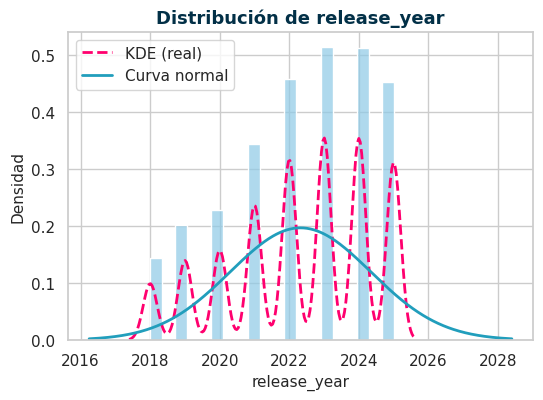

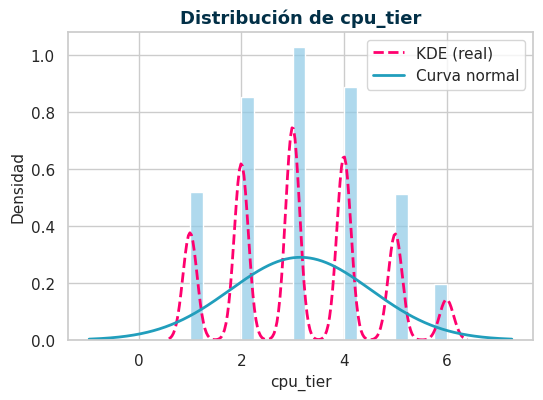

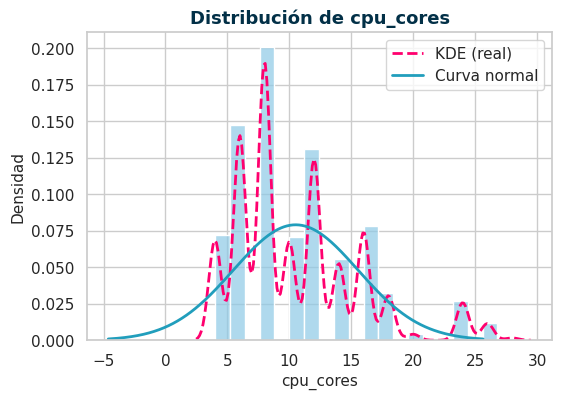

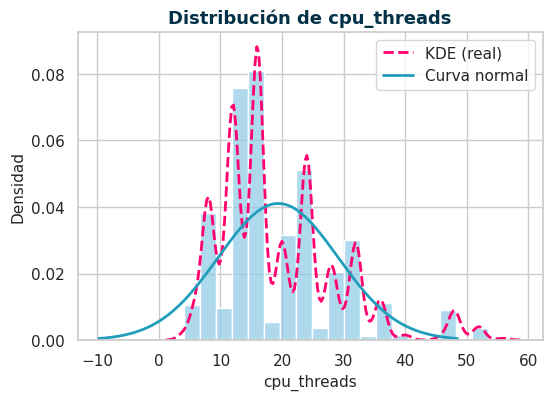

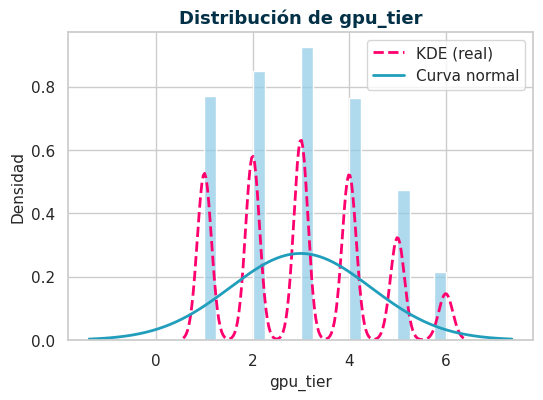

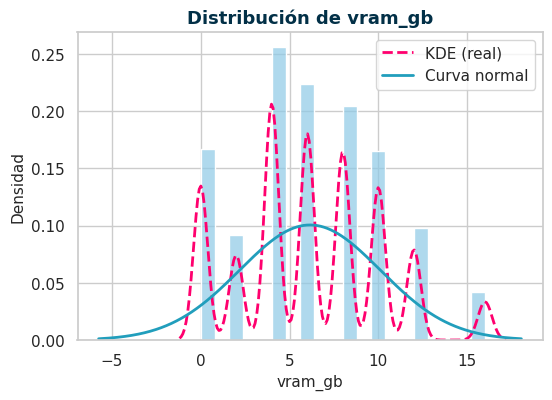

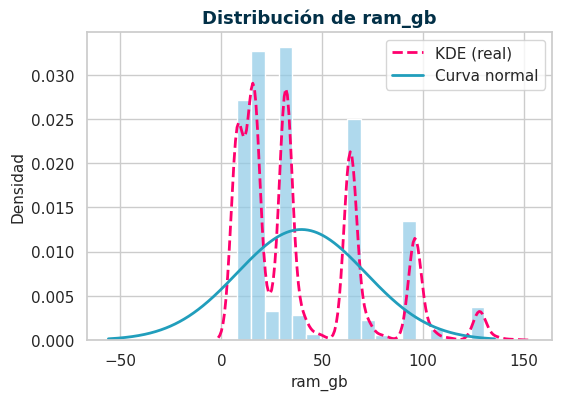

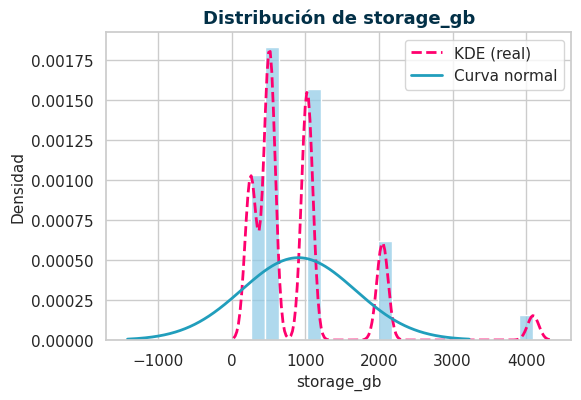

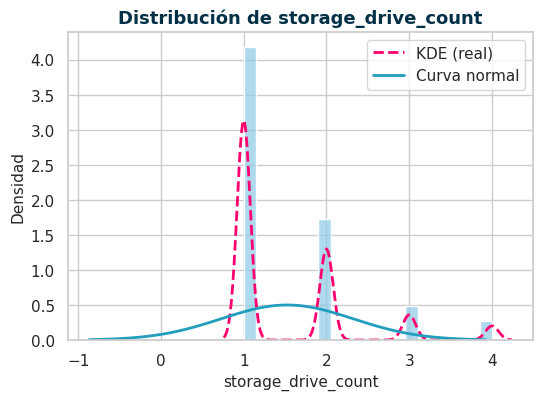

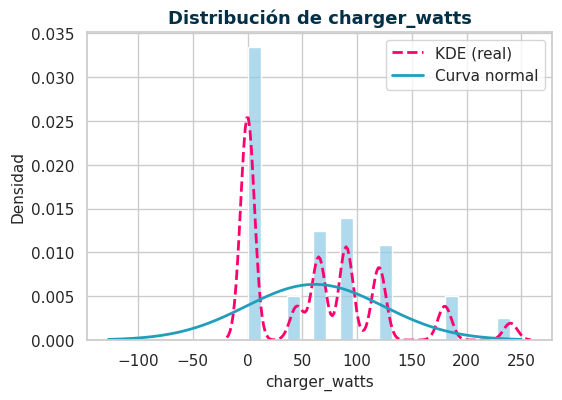

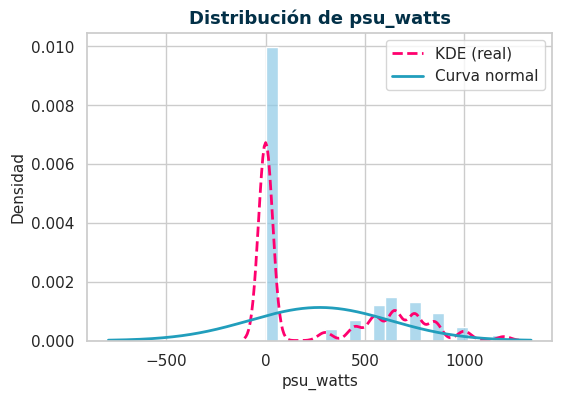

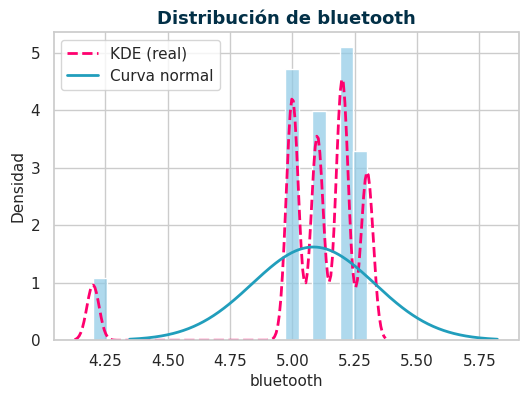

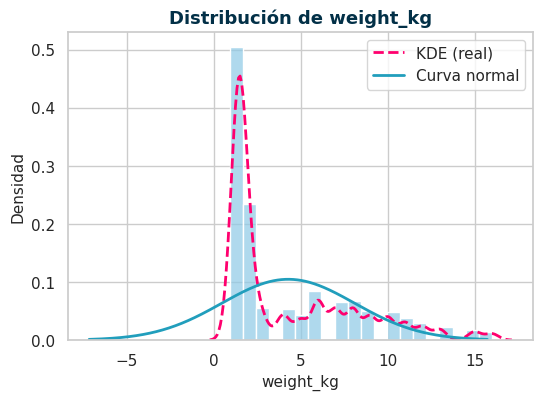

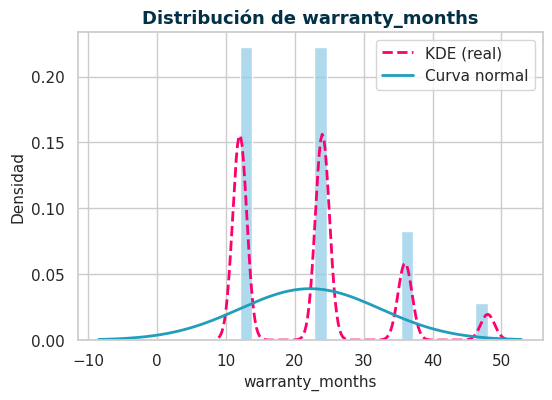

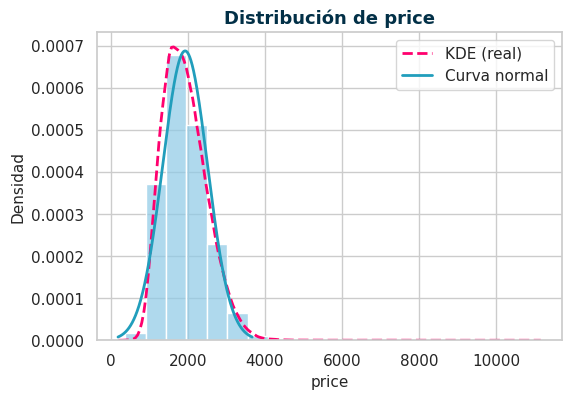

In [138]:
#Histogramas para las variables  numéricas
variables = ['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count',
       'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg',
       'warranty_months', 'price']

sns.set_theme(style="whitegrid")

hist_color = "#8ecae6"   # azul suave
kde_color = "#ff006e"    # rosa fuerte
norm_color = "#219ebc"   # azul medio

for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(compu_df[var], bins=20, color=hist_color, stat="density", edgecolor="white", alpha=0.7)
    sns.kdeplot(compu_df[var], color=kde_color, linewidth=2, linestyle="--", label="KDE (real)")

    mean = np.mean(compu_df[var])
    dv = np.std(compu_df[var])

    x_vals = np.linspace(mean - 3*dv, mean + 3*dv, 500)
    plt.plot(x_vals, norm.pdf(x_vals, mean, dv), color=norm_color, linewidth=2, linestyle="-", label="Curva normal")

    plt.legend()
    plt.title(f"Distribución de {var}", fontsize=13, fontweight="bold", color="#023047")
    plt.xlabel(var, fontsize=11)
    plt.ylabel("Densidad", fontsize=11)
    plt.show()
    print('\n')


In [139]:
#Columnas con variables categóricas
cols_num = compu_df.select_dtypes(include=['object', 'category']).columns
cols_num

Index(['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand',
       'gpu_model', 'storage_type', 'display_type', 'wifi'],
      dtype='object')

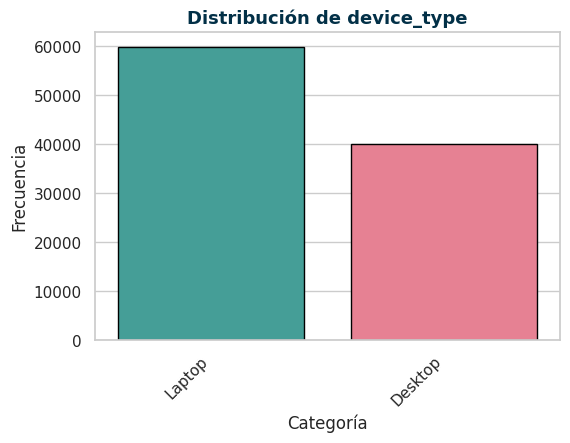

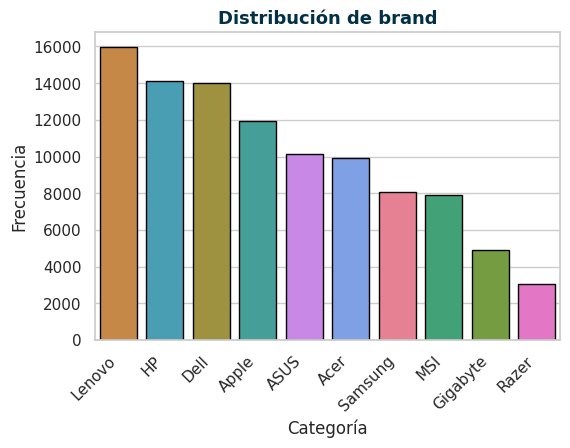

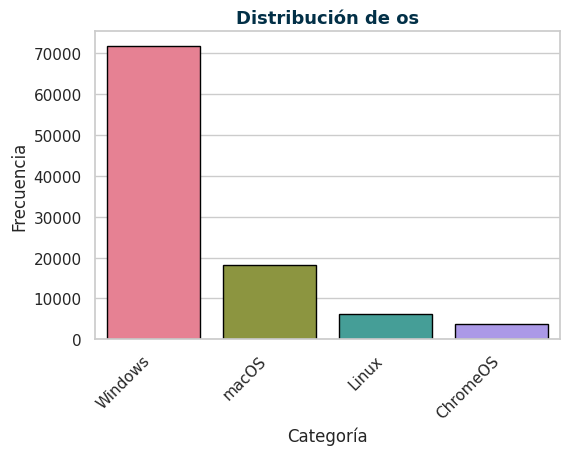

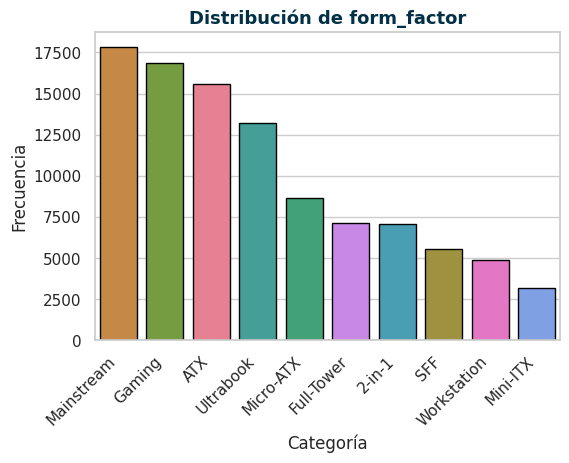

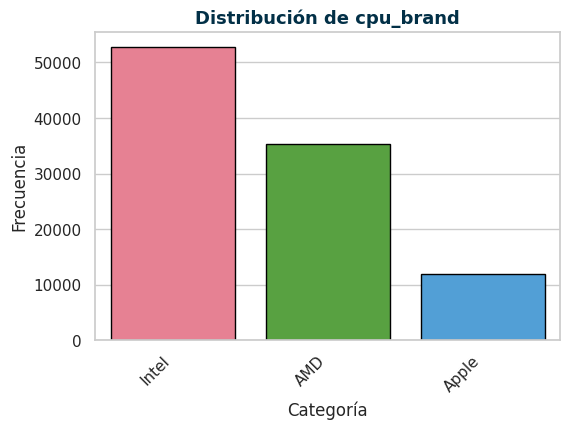

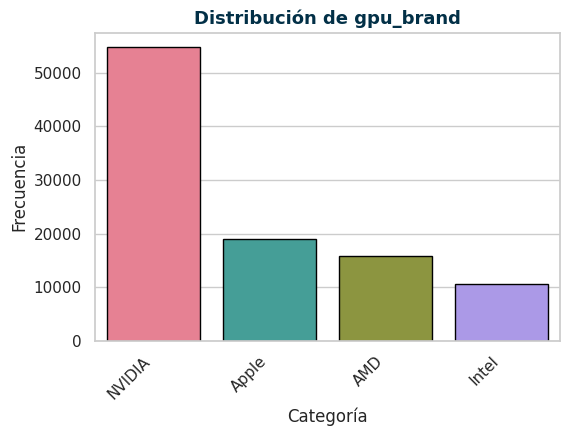

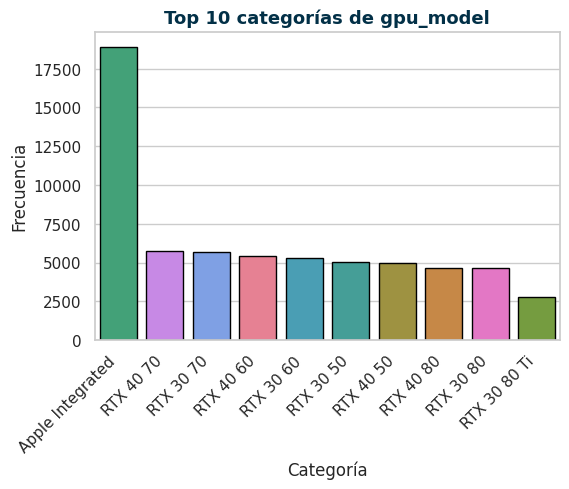

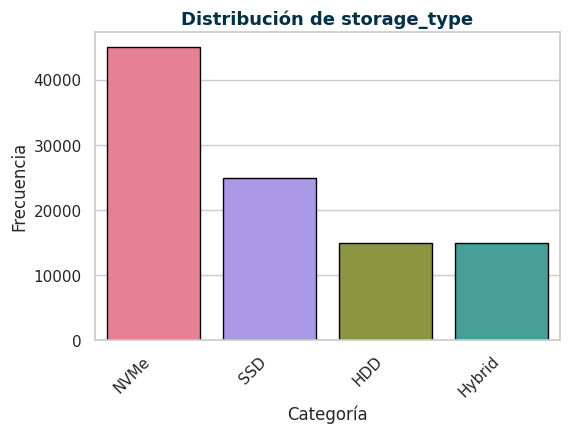

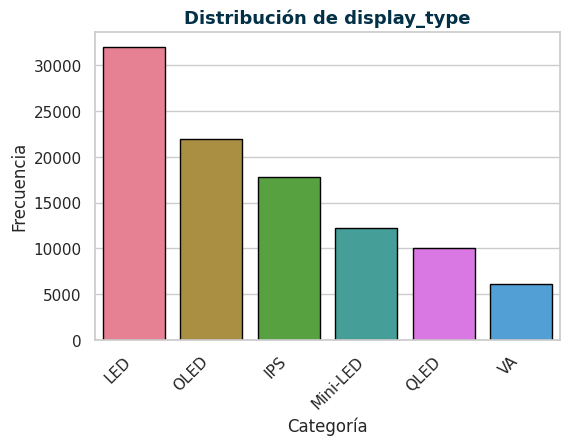

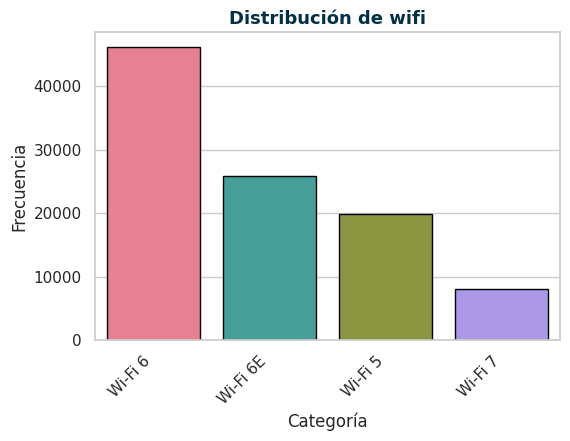

In [140]:
#Grafico de barras de variables categóricas

variables = ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand',
       'gpu_model', 'storage_type', 'display_type', 'wifi']

sns.set_theme(style="whitegrid")
paleta = "husl"

for var in variables:
    plt.figure(figsize=(6,4))

    if var == 'gpu_model':
        top_values = compu_df[var].value_counts().nlargest(10).index
        data = compu_df[compu_df[var].isin(top_values)]
        order = top_values
        title = f"Top 10 categorías de {var}"
    else:
        data = compu_df
        order = compu_df[var].value_counts().index
        title = f"Distribución de {var}"

    sns.countplot(
        x=var,
        data=data,
        hue = var,
        order=order,
        palette=paleta,
        edgecolor="black"
    )

    plt.title(title, fontsize=13, fontweight="bold", color="#023047")
    plt.xlabel("Categoría")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print("\n")



3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.
*Lo referente a capacidad de hardware podría ser lo siguiente: la variable device_type que, ya que hay diferencias de capacidad entre una laptop y una desktop los componentes varían entre una y otra, release_year que puede impactar en el rendimiento por fecha de salida, lo referente a CPU como cpu_tier, cpu_cores, cpu_threads condicionan nivel de CPU. Para GPU como gpu_model, gpu_tier, vram_gb, ram_gb ya que condicionan el nivel gráfico. El peso weight_kg porque hay una correlación positiva existente con psu_watts por eso la mantenemos. El precio debido que existe correlación con otras variables del dataframe. La variable Wifi porque ya es algo indispensable en cada computadora para poder tener Internet inalámbrico. En Almacenamiento con storage_type, storage_gb, storage_drive_count que impactan capacidad y finalmente para cuestión de potencia y rendimiento psu_watts (desktop) y charger_watts (laptop).*
*Redundantes o no orientadas a capacidad. Eliminar brand, cpu_brand, gpu_brand, redundantes por que ya existe cpu , gpu tier y gpu_model. Las variables de form_factor, display_type ya que se refieren a la forma y estética, por ejemplo. El sistema operativo os debido a que es software no hardware. Por conectividad bluetooth ya que es útil pero no tan importante. Finalmente, warranty_months ya que no tiene que ver con hardware.*



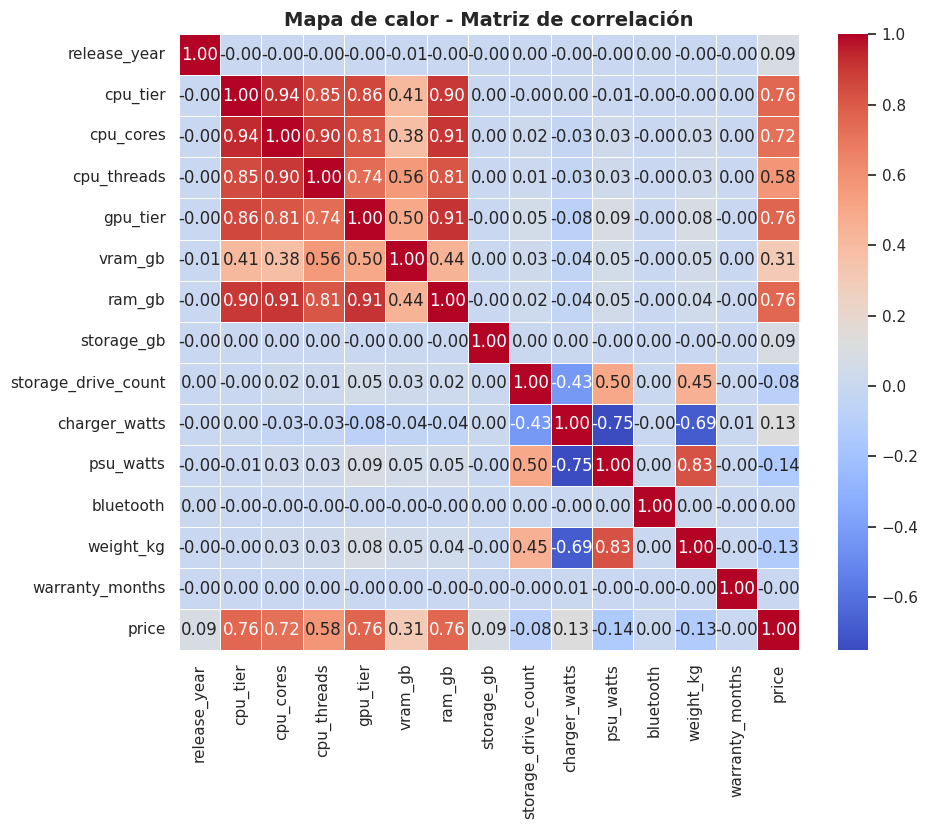

In [141]:
#Extraer variables numéricas, se calcula la correlación y se genera mapa de calor.
numericas_df = compu_df.select_dtypes(include=['number'])
corr = numericas_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Mapa de calor - Matriz de correlación", fontsize=14, fontweight="bold")
plt.show()

In [142]:
#Pares de variables con mayor correlacion

corr_matrix = corr.abs()

high_corr_df = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_df.columns = ['Variable 1', 'Variable 2', 'Correlación']
high_corr_df = high_corr_df[high_corr_df['Correlación'] > 0.9].sort_values(by='Correlación', ascending=False)

high_corr_df

,Variable 1,Variable 2,Correlación
14,cpu_tier,cpu_cores,0.937376
51,gpu_tier,ram_gb,0.912918
30,cpu_cores,ram_gb,0.906770


In [143]:
#Mostrar columnas del dataframe actual
compu_df.columns

Index(['device_type', 'brand', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_brand',
       'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type',
       'storage_gb', 'storage_drive_count', 'display_type', 'charger_watts',
       'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months',
       'price'],
      dtype='object')

In [144]:
#Eliminar columnas no referentes a capacidad de hardware
drop_cols = ['brand', 'os', 'form_factor','cpu_brand', 'gpu_brand', 'display_type', 'bluetooth',
             'warranty_months']
compu_df = compu_df.drop(columns=drop_cols)
compu_df

,device_type,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,charger_watts,psu_watts,wifi,weight_kg,price
0,Desktop,2022,3,12,24,RTX 40 60,2,6,16,NVMe,1024,1,0,750,Wi-Fi 6,11.00,1383.99
1,Laptop,2022,4,12,24,RTX 40 80,4,10,64,NVMe,512,1,120,0,Wi-Fi 6,2.03,2274.99
2,Desktop,2024,2,8,16,RTX 40 50,1,4,8,NVMe,512,2,0,850,Wi-Fi 6,7.00,1879.99
3,Desktop,2024,2,6,12,RX 7000 60,2,6,16,HDD,512,2,0,650,Wi-Fi 6,6.00,1331.99
4,Laptop,2024,5,16,32,RTX 30 80 Ti,5,12,96,NVMe,256,1,90,0,Wi-Fi 6,1.50,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,2023,4,12,24,RX 7000 70,3,8,32,HDD,2048,1,180,0,Wi-Fi 6,1.87,1712.99
99996,Laptop,2018,2,8,16,RX 6000 50,1,4,8,HDD,1024,1,65,0,Wi-Fi 6,1.37,1258.99
99997,Laptop,2020,2,6,10,RTX 20 60,2,6,16,NVMe,1024,1,180,0,Wi-Fi 6,1.17,1686.99
99998,Laptop,2020,4,12,24,RTX 30 70,3,8,32,NVMe,256,1,90,0,Wi-Fi 6,1.70,2164.99


4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [145]:
#Creamos copia del dataframe original
compu_trans = compu_df.copy()

#Genrar nueva columna years_since_release
compu_trans['years_since_release'] = date.today().year - compu_trans['release_year']
compu_trans = compu_trans.drop(columns=['release_year'])

compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,charger_watts,psu_watts,wifi,weight_kg,price,years_since_release
0,Desktop,3,12,24,RTX 40 60,2,6,16,NVMe,1024,1,0,750,Wi-Fi 6,11.00,1383.99,3
1,Laptop,4,12,24,RTX 40 80,4,10,64,NVMe,512,1,120,0,Wi-Fi 6,2.03,2274.99,3
2,Desktop,2,8,16,RTX 40 50,1,4,8,NVMe,512,2,0,850,Wi-Fi 6,7.00,1879.99,1
3,Desktop,2,6,12,RX 7000 60,2,6,16,HDD,512,2,0,650,Wi-Fi 6,6.00,1331.99,1
4,Laptop,5,16,32,RTX 30 80 Ti,5,12,96,NVMe,256,1,90,0,Wi-Fi 6,1.50,2681.99,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,4,12,24,RX 7000 70,3,8,32,HDD,2048,1,180,0,Wi-Fi 6,1.87,1712.99,2
99996,Laptop,2,8,16,RX 6000 50,1,4,8,HDD,1024,1,65,0,Wi-Fi 6,1.37,1258.99,7
99997,Laptop,2,6,10,RTX 20 60,2,6,16,NVMe,1024,1,180,0,Wi-Fi 6,1.17,1686.99,5
99998,Laptop,4,12,24,RTX 30 70,3,8,32,NVMe,256,1,90,0,Wi-Fi 6,1.70,2164.99,5


In [146]:
#Usar Kbinsdiscretizer
kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

compu_trans['vram_gb_kbin'] = kbins.fit_transform(compu_trans[['vram_gb']])
compu_trans = compu_trans.drop(columns=['vram_gb'])
compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,ram_gb,storage_type,storage_gb,storage_drive_count,charger_watts,psu_watts,wifi,weight_kg,price,years_since_release,vram_gb_kbin
0,Desktop,3,12,24,RTX 40 60,2,16,NVMe,1024,1,0,750,Wi-Fi 6,11.00,1383.99,3,2.0
1,Laptop,4,12,24,RTX 40 80,4,64,NVMe,512,1,120,0,Wi-Fi 6,2.03,2274.99,3,3.0
2,Desktop,2,8,16,RTX 40 50,1,8,NVMe,512,2,0,850,Wi-Fi 6,7.00,1879.99,1,1.0
3,Desktop,2,6,12,RX 7000 60,2,16,HDD,512,2,0,650,Wi-Fi 6,6.00,1331.99,1,2.0
4,Laptop,5,16,32,RTX 30 80 Ti,5,96,NVMe,256,1,90,0,Wi-Fi 6,1.50,2681.99,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,4,12,24,RX 7000 70,3,32,HDD,2048,1,180,0,Wi-Fi 6,1.87,1712.99,2,3.0
99996,Laptop,2,8,16,RX 6000 50,1,8,HDD,1024,1,65,0,Wi-Fi 6,1.37,1258.99,7,1.0
99997,Laptop,2,6,10,RTX 20 60,2,16,NVMe,1024,1,180,0,Wi-Fi 6,1.17,1686.99,5,2.0
99998,Laptop,4,12,24,RTX 30 70,3,32,NVMe,256,1,90,0,Wi-Fi 6,1.70,2164.99,5,3.0


In [147]:
#Imprimir valores de las orillas de los bins
kbins.bin_edges_

array([array([ 0.,  4.,  6.,  8., 16.])], dtype=object)

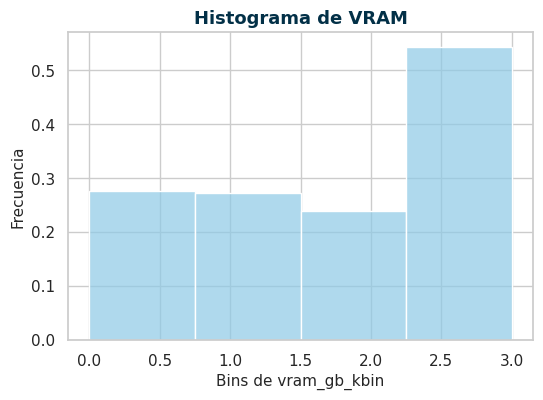

In [148]:
#Histograma de vram_gb_kbin

sns.set_theme(style="whitegrid")

hist_color = "#8ecae6"   # azul suave
kde_color = "#ff006e"    # rosa fuerte
norm_color = "#219ebc"   # azul medio

plt.figure(figsize=(6,4))
sns.histplot(compu_trans['vram_gb_kbin'], bins=4, color=hist_color, stat="density", edgecolor="white", alpha=0.7)

plt.title("Histograma de VRAM", fontsize=13, fontweight="bold", color="#023047")
plt.xlabel('Bins de vram_gb_kbin', fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.show()


5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
*Ocurre debido a que cada variable es exlusiva a si es pc de tipo desktop o laptop, es decir charger_watts solo tiene valor si el device type es laptop y psu_watts solo tiene valor si device type es Desktop pero estas variables indican la misma unidad de medida watts.*
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [149]:
#Combinar variables charger_watts y psu_watts
compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']
compu_trans = compu_trans.drop(columns=['charger_watts','psu_watts'])
compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,ram_gb,storage_type,storage_gb,storage_drive_count,wifi,weight_kg,price,years_since_release,vram_gb_kbin,power_watts
0,Desktop,3,12,24,RTX 40 60,2,16,NVMe,1024,1,Wi-Fi 6,11.00,1383.99,3,2.0,750
1,Laptop,4,12,24,RTX 40 80,4,64,NVMe,512,1,Wi-Fi 6,2.03,2274.99,3,3.0,120
2,Desktop,2,8,16,RTX 40 50,1,8,NVMe,512,2,Wi-Fi 6,7.00,1879.99,1,1.0,850
3,Desktop,2,6,12,RX 7000 60,2,16,HDD,512,2,Wi-Fi 6,6.00,1331.99,1,2.0,650
4,Laptop,5,16,32,RTX 30 80 Ti,5,96,NVMe,256,1,Wi-Fi 6,1.50,2681.99,1,3.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,4,12,24,RX 7000 70,3,32,HDD,2048,1,Wi-Fi 6,1.87,1712.99,2,3.0,180
99996,Laptop,2,8,16,RX 6000 50,1,8,HDD,1024,1,Wi-Fi 6,1.37,1258.99,7,1.0,65
99997,Laptop,2,6,10,RTX 20 60,2,16,NVMe,1024,1,Wi-Fi 6,1.17,1686.99,5,2.0,180
99998,Laptop,4,12,24,RTX 30 70,3,32,NVMe,256,1,Wi-Fi 6,1.70,2164.99,5,3.0,90


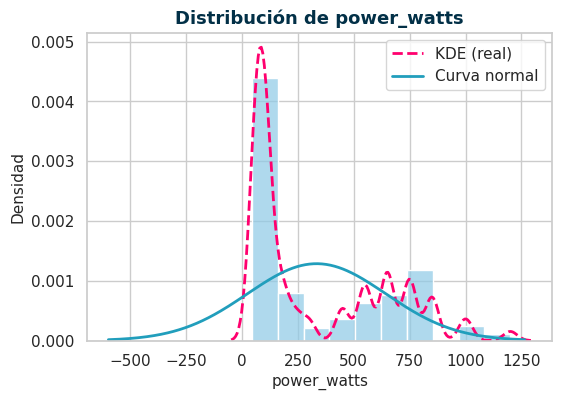

In [150]:
#Histograma de nueva columna power_watts
hist_color = "#8ecae6"   # azul suave
kde_color = "#ff006e"    # rosa fuerte
norm_color = "#219ebc"   # azul medio


plt.figure(figsize=(6,4))
sns.histplot(compu_trans['power_watts'], bins=10, color=hist_color, stat="density", edgecolor="white", alpha=0.7)
sns.kdeplot(compu_trans['power_watts'], color=kde_color, linewidth=2, linestyle="--", label="KDE (real)")

mean = np.mean(compu_trans['power_watts'])
dv = np.std(compu_trans['power_watts'])

x_vals = np.linspace(mean - 3*dv, mean + 3*dv, 500)
plt.plot(x_vals, norm.pdf(x_vals, mean, dv), color=norm_color, linewidth=2, linestyle="-", label="Curva normal")

plt.legend()
plt.title("Distribución de power_watts", fontsize=13, fontweight="bold", color="#023047")
plt.xlabel('power_watts', fontsize=11)
plt.ylabel("Densidad", fontsize=11)
plt.show()



6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.
*La mejor fue la transformación de boxcox ya que nos da un valor de correlación de Pearson de 0.999  es decir la distribución de sus datos transformados se acerca mucho a una distribución gausseana además su valor de sesgo es de 0.0 lo que indica que al transformar los datos su distribución es simétrica.*

In [151]:
def graficar_variable(df, columna, bins=20):

    hist_color = "#8ecae6"   # azul suave
    kde_color = "#ff006e"    # rosa fuerte
    norm_color = "#219ebc"   # azul medio

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

    # Histograma

    skew = df[columna].skew()
    sns.histplot(df[columna], bins=bins, color=hist_color, stat="density", alpha=0.7, label=f"Sesgo={skew:.3f}" , ax=axes[0])
    sns.kdeplot(df[columna], color=kde_color, linewidth=2, linestyle="--", label="KDE (real)", ax=axes[0])
    axes[0].legend()
    axes[0].set_title(f"Histograma de {columna}", fontsize=13, fontweight="bold", color="#023047")

    mean = np.mean(df[columna])
    dv = np.std(df[columna])

    x_vals = np.linspace(mean - 3*dv, mean + 3*dv, 500)
    axes[0].plot(x_vals, norm.pdf(x_vals, mean, dv), color=norm_color, linewidth=2, linestyle="-", label="Curva normal")
    axes[0].legend()

     # Boxplot

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Umbrales
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Filtrar outliers
    outliers = df[(df[columna] < lower) | (df[columna] > upper)]
    num_outliers = len(outliers)

    sns.boxplot(x=df[columna], boxprops=dict(facecolor=hist_color, alpha=0.7), showmeans=True,
                meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"},ax=axes[1])
    axes[1].set_title(f"Boxplot de {columna}", fontsize=13, fontweight="bold", color="#023047")

    axes[1].text(
    x=df[columna].max(),  # posición a la derecha del gráfico
    y=0,                  # posición vertical (único boxplot)
    s=f"Outliers: {num_outliers}",
    fontsize=11,
    fontweight="bold",
    color="red",
    ha="right",
    va="bottom")

    # Q-Q plot
    # datos sin NaN
    serie = df[columna].dropna().values

    # probplot: devuelve ((osm, osr), (slope, intercept, r))
    (osm, osr), (slope, intercept, r) = stats.probplot(serie, dist="norm", plot=None)

    # puntos
    axes[2].scatter(osm, osr, color="#219ebc", alpha=0.7, label="Datos")

    # línea de referencia (recta ajustada)
    xline = np.linspace(osm.min(), osm.max(), 100)
    axes[2].plot(xline, slope * xline + intercept, color="#ff006e", linestyle="--", label=f"Línea (r={r:.3f})")

    axes[2].set_title(f"Q–Q Plot de {columna}", fontsize=13, fontweight="bold", color="#023047")
    axes[2].set_xlabel("Cuantiles teóricos (Normal)")
    axes[2].set_ylabel("Cuantiles observados")
    axes[2].legend()

    plt.show()

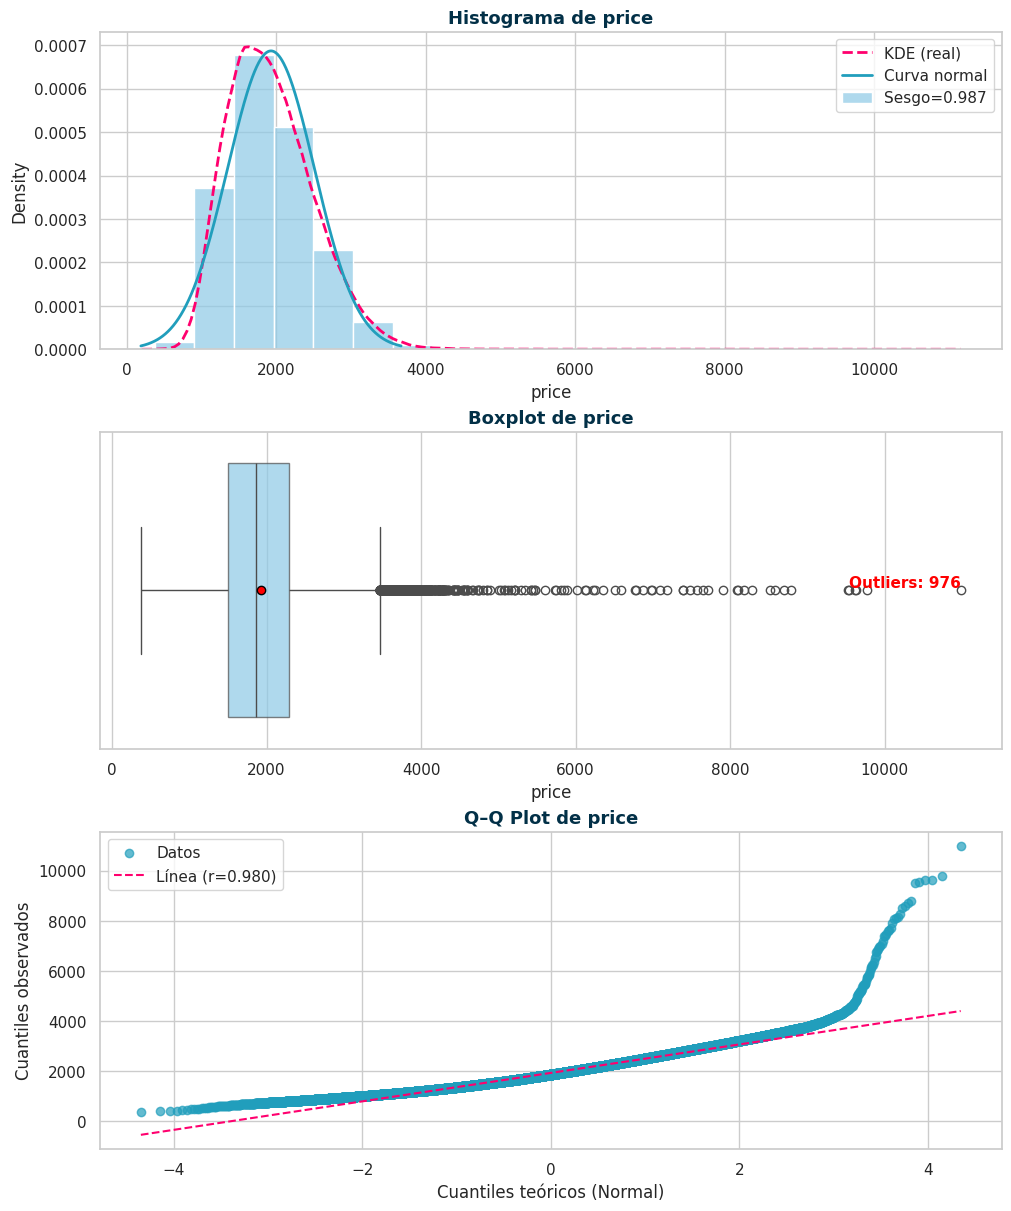

In [152]:
#Variable Price
graficar_variable(compu_trans, 'price', 20)

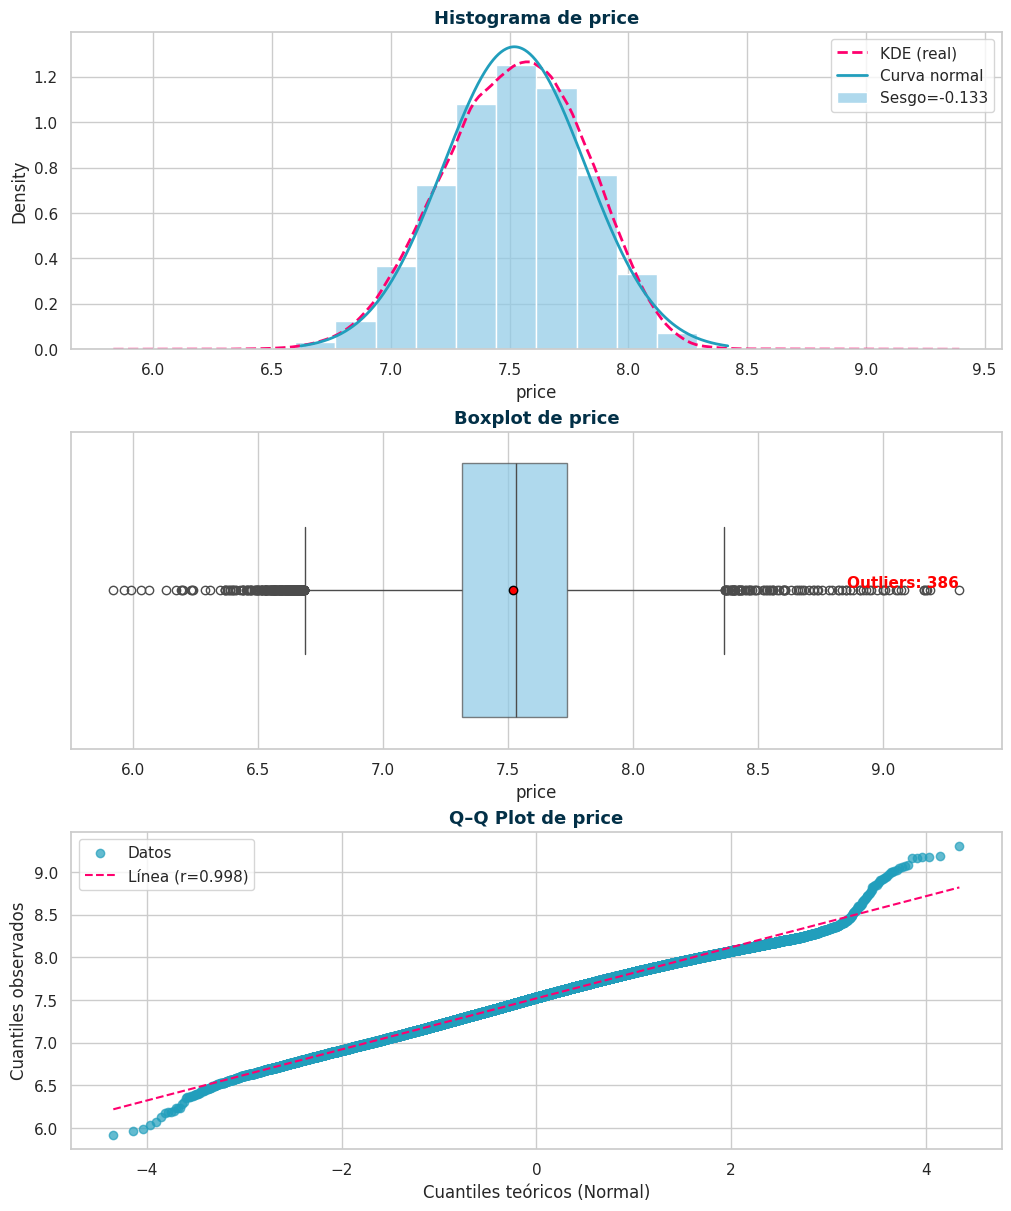

In [153]:
#Copiamos el dataframe a uno nuevo, hacemos la transformación logarítmica y usamos la función anterior para graficar.
compu_price_log = compu_trans.copy()

transformer = FunctionTransformer(func=np.log, inverse_func=np.exp)
compu_price_log['price'] = transformer.transform(compu_price_log[['price']])

graficar_variable(compu_price_log, 'price', 20)

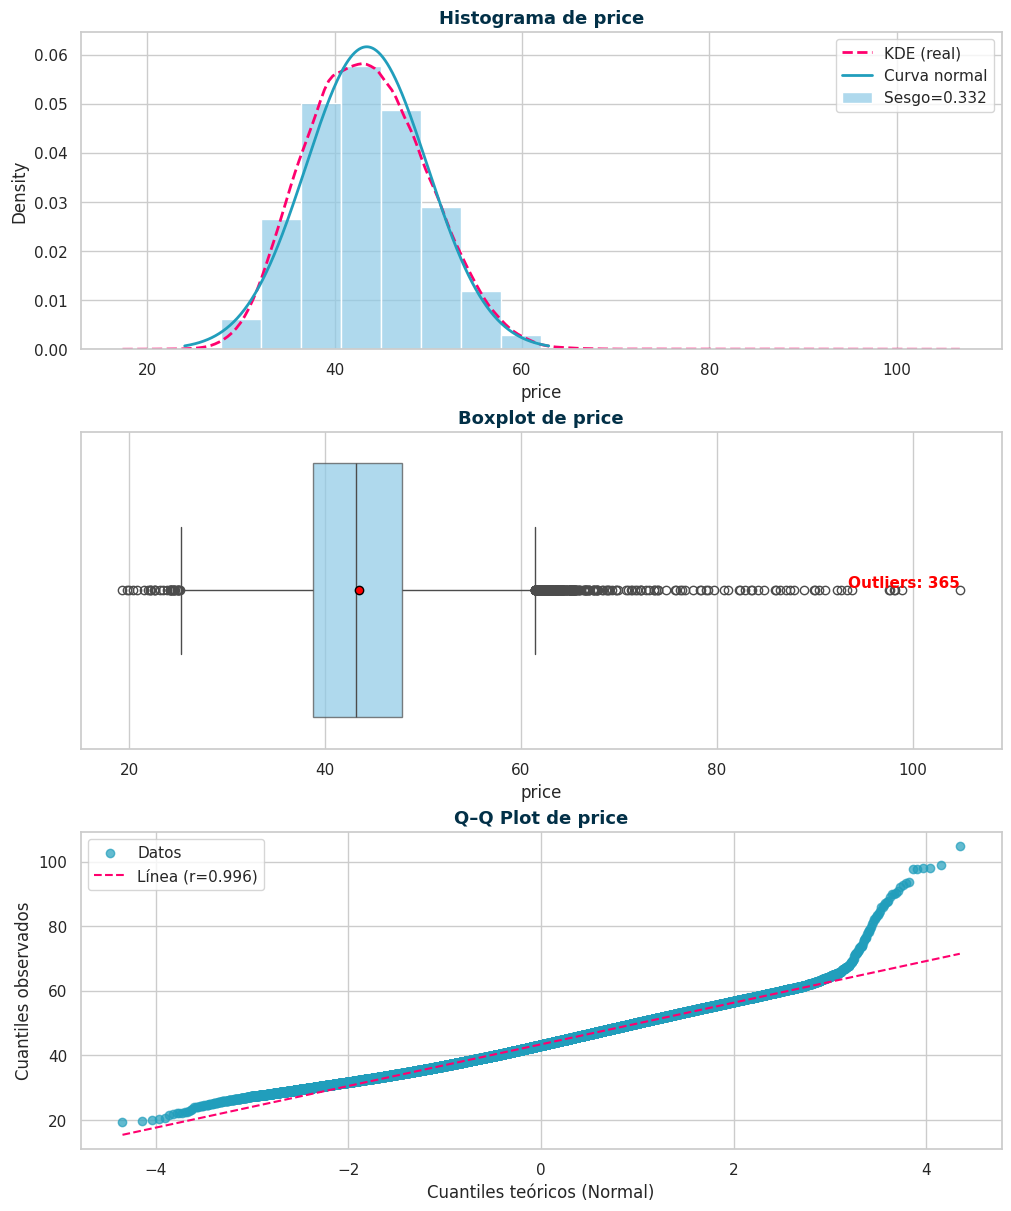

In [154]:
#Copiamos el dataframe a uno nuevo, hacemos la transformación raíz cuadrada y usamos la función anterior para graficar.
compu_price_sqrt = compu_trans.copy()

transformer = FunctionTransformer(func=lambda x: np.round(np.sqrt(x), 2))
compu_price_sqrt['price'] = transformer.transform(compu_price_sqrt[['price']])

graficar_variable(compu_price_sqrt, 'price', 20)

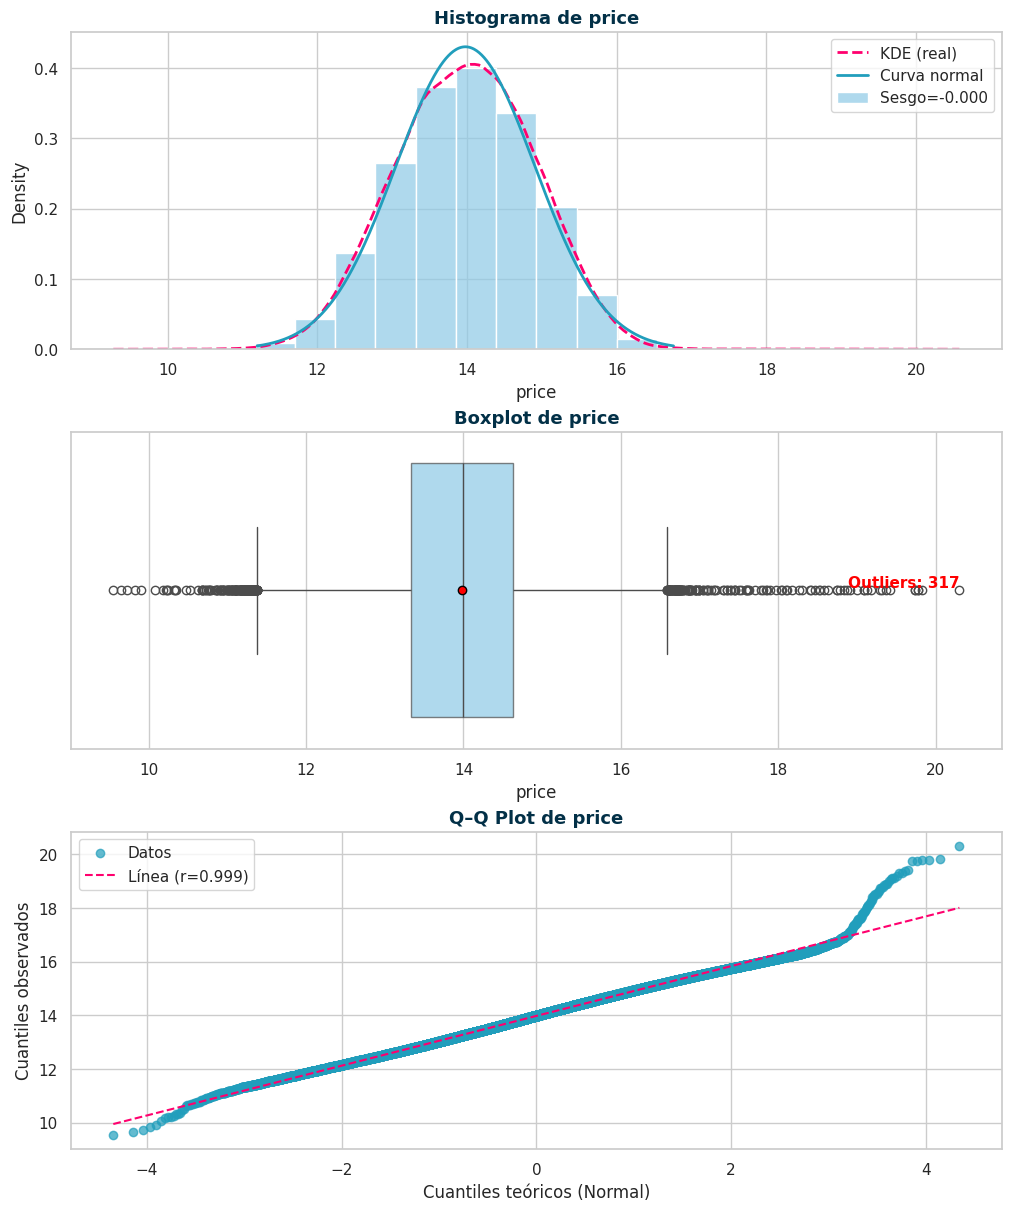

In [155]:
#Copiamos el dataframe a uno nuevo, hacemos la transformación boxcox y usamos la función anterior para graficar.
compu_price_boxcox = compu_trans.copy()

transformer = PowerTransformer(method="box-cox", standardize=False)

if (compu_price_boxcox['price'] <= 0).any():
    raise ValueError("Box-Cox requiere valores positivos. Aplica una corrección primero.")

compu_price_boxcox['price'] = transformer.fit_transform(compu_price_boxcox[['price']])

graficar_variable(compu_price_boxcox, 'price', 20)

In [156]:
#Aplicamos el transformador de boxcox al dataframe original compu_trans para weight_kg, power_watts y price
cols = ['price', 'weight_kg','power_watts']
transformer = PowerTransformer(method="box-cox", standardize=False)

for i in cols:
      if (compu_trans[i] <= 0).any():
          raise ValueError("Box-Cox requiere valores positivos. Aplica una corrección primero.")
      else:
        compu_trans[i] = transformer.fit_transform(compu_trans[[i]])

compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,ram_gb,storage_type,storage_gb,storage_drive_count,wifi,weight_kg,price,years_since_release,vram_gb_kbin,power_watts
0,Desktop,3,12,24,RTX 40 60,2,16,NVMe,1024,1,Wi-Fi 6,1.423738,13.084409,3,2.0,4.027280
1,Laptop,4,12,24,RTX 40 80,4,64,NVMe,512,1,Wi-Fi 6,0.600182,14.616126,3,3.0,3.309631
2,Desktop,2,8,16,RTX 40 50,1,8,NVMe,512,2,Wi-Fi 6,1.264217,14.014803,1,1.0,4.068825
3,Desktop,2,6,12,RX 7000 60,2,16,HDD,512,2,Wi-Fi 6,1.201393,12.971066,1,2.0,3.978717
4,Laptop,5,16,32,RTX 30 80 Ti,5,96,NVMe,256,1,Wi-Fi 6,0.368418,15.149121,1,3.0,3.175932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,4,12,24,RX 7000 70,3,32,HDD,2048,1,Wi-Fi 6,0.540589,13.727684,2,3.0,3.487612
99996,Laptop,2,8,16,RX 6000 50,1,8,HDD,1024,1,Wi-Fi 6,0.292160,12.805434,7,1.0,3.016840
99997,Laptop,2,6,10,RTX 20 60,2,16,NVMe,1024,1,Wi-Fi 6,0.151229,13.680862,5,2.0,3.487612
99998,Laptop,4,12,24,RTX 30 70,3,32,NVMe,256,1,Wi-Fi 6,0.468392,14.458197,5,3.0,3.175932


In [157]:
#Variables numericas
cols_num = compu_trans.select_dtypes(include=['int64', 'float64']).columns
cols_num

Index(['cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier', 'ram_gb',
       'storage_gb', 'storage_drive_count', 'weight_kg', 'price',
       'years_since_release', 'vram_gb_kbin', 'power_watts'],
      dtype='object')

7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [158]:
#Aplicar MinMaxScaler a compu_trans df
scaler = MinMaxScaler(feature_range=(0, 1))

cols = ['cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier', 'ram_gb',
       'storage_gb', 'storage_drive_count', 'weight_kg', 'price',
       'years_since_release', 'vram_gb_kbin', 'power_watts']

compu_trans[cols] = scaler.fit_transform(compu_trans[cols])
compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,ram_gb,storage_type,storage_gb,storage_drive_count,wifi,weight_kg,price,years_since_release,vram_gb_kbin,power_watts
0,Desktop,0.4,0.333333,0.384615,RTX 40 60,0.2,0.058824,NVMe,0.200000,0.000000,Wi-Fi 6,0.932995,0.328669,0.428571,0.666667,0.887860
1,Laptop,0.6,0.333333,0.384615,RTX 40 80,0.6,0.411765,NVMe,0.066667,0.000000,Wi-Fi 6,0.423737,0.471202,0.428571,1.000000,0.357238
2,Desktop,0.2,0.166667,0.230769,RTX 40 50,0.0,0.000000,NVMe,0.066667,0.333333,Wi-Fi 6,0.834353,0.415246,0.142857,0.333333,0.918578
3,Desktop,0.2,0.083333,0.153846,RX 7000 60,0.2,0.058824,HDD,0.066667,0.333333,Wi-Fi 6,0.795505,0.318122,0.142857,0.666667,0.851953
4,Laptop,0.8,0.500000,0.538462,RTX 30 80 Ti,0.8,0.647059,NVMe,0.000000,0.000000,Wi-Fi 6,0.280423,0.520800,0.142857,1.000000,0.258382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,0.6,0.333333,0.384615,RX 7000 70,0.4,0.176471,HDD,0.466667,0.000000,Wi-Fi 6,0.386887,0.388528,0.285714,1.000000,0.488835
99996,Laptop,0.2,0.166667,0.230769,RX 6000 50,0.0,0.000000,HDD,0.200000,0.000000,Wi-Fi 6,0.233268,0.302709,1.000000,0.333333,0.140751
99997,Laptop,0.2,0.083333,0.115385,RTX 20 60,0.2,0.058824,NVMe,0.200000,0.000000,Wi-Fi 6,0.146121,0.384171,0.714286,0.666667,0.488835
99998,Laptop,0.6,0.333333,0.384615,RTX 30 70,0.4,0.176471,NVMe,0.000000,0.000000,Wi-Fi 6,0.342243,0.456506,0.714286,1.000000,0.258382


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [159]:
#Ordinal encoder a wifi
orden_wifi = ['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']

encoder = OrdinalEncoder(categories=[orden_wifi])
compu_trans['wifi']= encoder.fit_transform(compu_trans[['wifi']])


In [160]:
#Escalar wifi a 0-1 con MixMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))


compu_trans['wifi'] = scaler.fit_transform(compu_trans[['wifi']]).ravel()
compu_trans

,device_type,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,ram_gb,storage_type,storage_gb,storage_drive_count,wifi,weight_kg,price,years_since_release,vram_gb_kbin,power_watts
0,Desktop,0.4,0.333333,0.384615,RTX 40 60,0.2,0.058824,NVMe,0.200000,0.000000,0.333333,0.932995,0.328669,0.428571,0.666667,0.887860
1,Laptop,0.6,0.333333,0.384615,RTX 40 80,0.6,0.411765,NVMe,0.066667,0.000000,0.333333,0.423737,0.471202,0.428571,1.000000,0.357238
2,Desktop,0.2,0.166667,0.230769,RTX 40 50,0.0,0.000000,NVMe,0.066667,0.333333,0.333333,0.834353,0.415246,0.142857,0.333333,0.918578
3,Desktop,0.2,0.083333,0.153846,RX 7000 60,0.2,0.058824,HDD,0.066667,0.333333,0.333333,0.795505,0.318122,0.142857,0.666667,0.851953
4,Laptop,0.8,0.500000,0.538462,RTX 30 80 Ti,0.8,0.647059,NVMe,0.000000,0.000000,0.333333,0.280423,0.520800,0.142857,1.000000,0.258382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,0.6,0.333333,0.384615,RX 7000 70,0.4,0.176471,HDD,0.466667,0.000000,0.333333,0.386887,0.388528,0.285714,1.000000,0.488835
99996,Laptop,0.2,0.166667,0.230769,RX 6000 50,0.0,0.000000,HDD,0.200000,0.000000,0.333333,0.233268,0.302709,1.000000,0.333333,0.140751
99997,Laptop,0.2,0.083333,0.115385,RTX 20 60,0.2,0.058824,NVMe,0.200000,0.000000,0.333333,0.146121,0.384171,0.714286,0.666667,0.488835
99998,Laptop,0.6,0.333333,0.384615,RTX 30 70,0.4,0.176471,NVMe,0.000000,0.000000,0.333333,0.342243,0.456506,0.714286,1.000000,0.258382


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [161]:
#Utilizar Binary encoder
encoder = BinaryEncoder(cols=['gpu_model'])
bin_df = encoder.fit_transform(compu_trans[['gpu_model']])
bin_df


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1
...,...,...,...,...,...,...
99995,1,0,0,0,1,1
99996,0,1,1,0,1,1
99997,1,0,0,0,0,0
99998,0,0,1,0,1,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [162]:
#Variables categoricas
cols_num = compu_trans.select_dtypes(include=['object', 'category']).columns
cols_num

Index(['device_type', 'gpu_model', 'storage_type'], dtype='object')

In [163]:
#Usar onehotencoder para las variables categoricas restantes
cat_cols = ['device_type', 'storage_type']

encoder = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = encoder.fit_transform(compu_trans[cat_cols])

ohe_colnames = encoder.get_feature_names_out(cat_cols)
ohe_df = pd.DataFrame(ohe_array, columns=ohe_colnames, index=compu_trans.index)
ohe_df

,device_type_Laptop,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0
...,...,...,...,...
99995,1.0,0.0,0.0,0.0
99996,1.0,0.0,0.0,0.0
99997,1.0,0.0,1.0,0.0
99998,1.0,0.0,1.0,0.0


In [164]:
#Combinar con compu_trans
cols_drop = ['device_type','gpu_model','storage_type']

compu_trans.drop(columns=cols_drop, inplace=True)
compu_trans = pd.concat([compu_trans, bin_df, ohe_df], axis=1)
compu_trans

,cpu_tier,cpu_cores,cpu_threads,gpu_tier,ram_gb,storage_gb,storage_drive_count,wifi,weight_kg,price,...,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5,device_type_Laptop,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
0,0.4,0.333333,0.384615,0.2,0.058824,0.200000,0.000000,0.333333,0.932995,0.328669,...,0,0,0,0,0,1,0.0,0.0,1.0,0.0
1,0.6,0.333333,0.384615,0.6,0.411765,0.066667,0.000000,0.333333,0.423737,0.471202,...,0,0,0,0,1,0,1.0,0.0,1.0,0.0
2,0.2,0.166667,0.230769,0.0,0.000000,0.066667,0.333333,0.333333,0.834353,0.415246,...,0,0,0,0,1,1,0.0,0.0,1.0,0.0
3,0.2,0.083333,0.153846,0.2,0.058824,0.066667,0.333333,0.333333,0.795505,0.318122,...,0,0,0,1,0,0,0.0,0.0,0.0,0.0
4,0.8,0.500000,0.538462,0.8,0.647059,0.000000,0.000000,0.333333,0.280423,0.520800,...,0,0,0,1,0,1,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.6,0.333333,0.384615,0.4,0.176471,0.466667,0.000000,0.333333,0.386887,0.388528,...,1,0,0,0,1,1,1.0,0.0,0.0,0.0
99996,0.2,0.166667,0.230769,0.0,0.000000,0.200000,0.000000,0.333333,0.233268,0.302709,...,0,1,1,0,1,1,1.0,0.0,0.0,0.0
99997,0.2,0.083333,0.115385,0.2,0.058824,0.200000,0.000000,0.333333,0.146121,0.384171,...,1,0,0,0,0,0,1.0,0.0,1.0,0.0
99998,0.6,0.333333,0.384615,0.4,0.176471,0.000000,0.000000,0.333333,0.342243,0.456506,...,0,0,1,0,1,1,1.0,0.0,1.0,0.0


In [165]:
compu_trans.describe()

,cpu_tier,cpu_cores,cpu_threads,gpu_tier,ram_gb,storage_gb,storage_drive_count,wifi,weight_kg,price,...,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5,device_type_Laptop,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.271489,0.295629,0.398270,0.233135,0.168733,0.174993,0.406670,0.517032,0.411800,...,0.118160,0.224950,0.38106,0.482690,0.525590,0.686920,0.598440,0.149810,0.450590,0.249370
std,0.274635,0.210171,0.186893,0.291929,0.234579,0.201626,0.265761,0.284834,0.293982,0.086261,...,0.322799,0.417551,0.48565,0.499703,0.499347,0.463749,0.490216,0.356887,0.497555,0.432651
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.083333,0.153846,0.200000,0.058824,0.066667,0.000000,0.333333,0.280423,0.351779,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.166667,0.230769,0.400000,0.176471,0.066667,0.000000,0.333333,0.417162,0.412776,...,0.000000,0.000000,0.00000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.416667,0.384615,0.600000,0.411765,0.200000,0.333333,0.666667,0.834353,0.472899,...,0.000000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
